In [4]:
%reload_ext autoreload
%autoreload 2
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LightSource
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import pandas as pd
import torch
import scipy
import sys
import os
import xarray as xr
sys.path.append('../')

from src.utilities import low_high_marginal_percentile, load_ase_datasets, reverse_standardize
from src.ice import enthalpy_to_temperature
from src.plotting import Plotting

# ---------------------------------------------------------------
# Load auxiliary data
# ---------------------------------------------------------------
aux_data = load_ase_datasets()
xs_ase, ys_ase = aux_data['coords']['xs'], aux_data['coords']['ys']
print("Keys of the auxiliary data dictionary:", aux_data.keys())

nx, ny = aux_data['coords']['X'].shape

# ---------------------------------------------------------------
# INPUT DATA - BASAL ENTHALPY AND GHF 
# ---------------------------------------------------------------
posterior_sample_name = "samples/hmc_md_beta3_betaw0.01.pt.npy"
H_filename       = 'H_gridded.mat'
Eb_mean_filename = 'trainingAll_Eb_sim_mean.mat' # for reverse standardization
Eb_std_filename  = 'trainingAll_Eb_sim_std.mat'
# ---------------------------------------------------------------
# ---------------------------------------------------------------

data_path        = os.getenv('RAW_DATA_PATH')
param_path       = os.getenv('PARAM_PATH')
inference_path   = os.getenv('INFERENCE_READY_DATA_PATH')
posterior_path   = os.getenv('POSTERIOR_PATH')
folder = data_path

# LOADING
preprocess_param = pd.read_csv(param_path, index_col=0)
Eb_standardize_epsilon = preprocess_param['Eb_standardization_epsilon'].values[0]

posterior_sample_path = os.path.join(posterior_path, posterior_sample_name)
GHF_sample_path       = os.path.join(posterior_path, "../GHF/inferred-GHF.npy")

GHF_samples           = np.load(GHF_sample_path)
posterior_samples     = np.load(posterior_sample_path)
num_Eb_samples        = posterior_samples.shape[0]
num_GHF_samples       = GHF_samples.shape[0]


# load standardization factors for reverse standardization
Eb_mean          = scipy.io.loadmat(os.path.join(folder, Eb_mean_filename))
Eb_std           = scipy.io.loadmat(os.path.join(folder, Eb_std_filename))
Eb_mean = np.nan_to_num(Eb_mean['Eb_mean'], nan=0.0).flatten()
Eb_std  = np.nan_to_num(Eb_std['Eb_std'], nan=0.0).flatten()

# ── Convert to temperature ─────────────────────────────────────────────
d2T_samples = np.zeros_like(posterior_samples)

for i in range(num_Eb_samples):
    Eb_i   = torch.from_numpy(posterior_samples[i])
    Tpmp_i = torch.from_numpy(aux_data['Tpmp']) if isinstance(aux_data['Tpmp'], np.ndarray) else aux_data['Tpmp']
    # reverse standardization
    Eb_i_ori = reverse_standardize(Eb_i,
                                   Eb_mean, 
                                   Eb_std, 
                                   method='relaxation',
                                   epsilon=Eb_standardize_epsilon)
    d2T_samples[i] = aux_data['Tpmp'].ravel() - enthalpy_to_temperature(Eb_i_ori, Tpmp_i.ravel()).numpy()
    d2T_samples[i][aux_data['mask'].ravel() == 0] = np.nan


  [load_ase_datasets] Loading reference coordinates …
  [load_ase_datasets] Loading Bedmap3 …
  [load_ase_datasets] Computing Tpmp …
  [load_ase_datasets] Computing surface slope …
  [load_ase_datasets] Loading velocity …
  [load_ase_datasets] Loading domain mask …
  [load_ase_datasets] Loading surface mass balance (SMB) …
  [load_ase_datasets] All datasets ready.
Keys of the auxiliary data dictionary: dict_keys(['coords', 'sdem', 'bed', 'H', 'Tpmp', 'slope_x', 'slope_y', 'slope_mag', 'vx', 'vy', 'vel', 'mask', 'domain_bound_line', 'smb'])


In [5]:
GHF_samples = GHF_samples * 1e3 # convert from W/m^2 to mW/m^2
for i in range(num_GHF_samples):
    GHF_samples[i][aux_data['mask'].ravel() == 0] = np.nan

ghf_mean = np.mean(GHF_samples, axis=0).reshape(nx, ny)
ghf_max_level = 150
ghf_min_level = 50
ghf_colormap = "cividis"


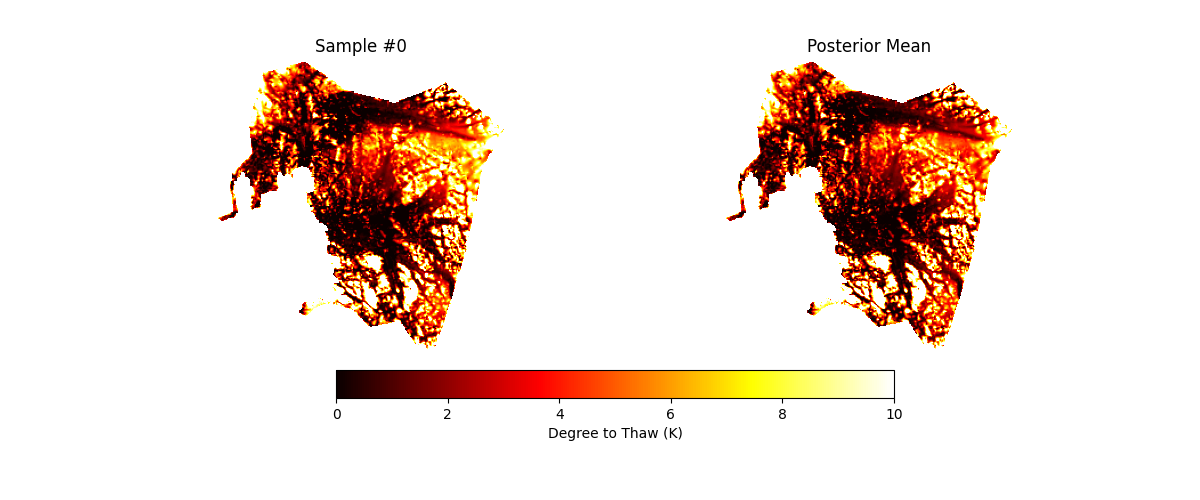

In [12]:
import ipywidgets as widgets
from IPython.display import display
import matplotlib.pyplot as plt
import numpy as np
%matplotlib widget 

# precompute once
vmin    = 0
vmax    = 10
d2T_mean = d2T_samples.mean(axis=0).reshape(nx, ny)

# ── build figure once, update data in-place ───────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
plt.subplots_adjust(bottom=0.15)

im0 = axes[0].imshow(d2T_samples[0].reshape(nx, ny),
                     vmin=vmin, vmax=vmax, cmap='hot', origin='lower')
im1 = axes[1].imshow(d2T_mean,
                     vmin=vmin, vmax=vmax, cmap='hot', origin='lower')

for ax in axes:
    ax.axis('off')
axes[1].set_title('Posterior Mean')

plt.colorbar(im0, ax=axes, orientation='horizontal',
             label='Degree to Thaw (K)', shrink=0.6, pad=0.05)

title = axes[0].set_title('Sample #0')

def update(sample_idx):
    im0.set_data(d2T_samples[sample_idx].reshape(nx, ny))
    title.set_text(f'Sample #{sample_idx}')
    fig.canvas.draw_idle()   # ← only redraws changed pixels, very fast

slider = widgets.IntSlider(
    value=0, min=0, max=num_Eb_samples - 1, step=1,
    description='Sample:', continuous_update=True,   # ← updates while dragging
    layout=widgets.Layout(width='500px')
)
play = widgets.Play(
    value=0, min=0, max=num_Eb_samples - 1,
    step=1, interval=300
)
widgets.jslink((play, 'value'), (slider, 'value'))
widgets.interactive_output(update, {'sample_idx': slider})

display(widgets.VBox([widgets.HBox([play, slider])]))


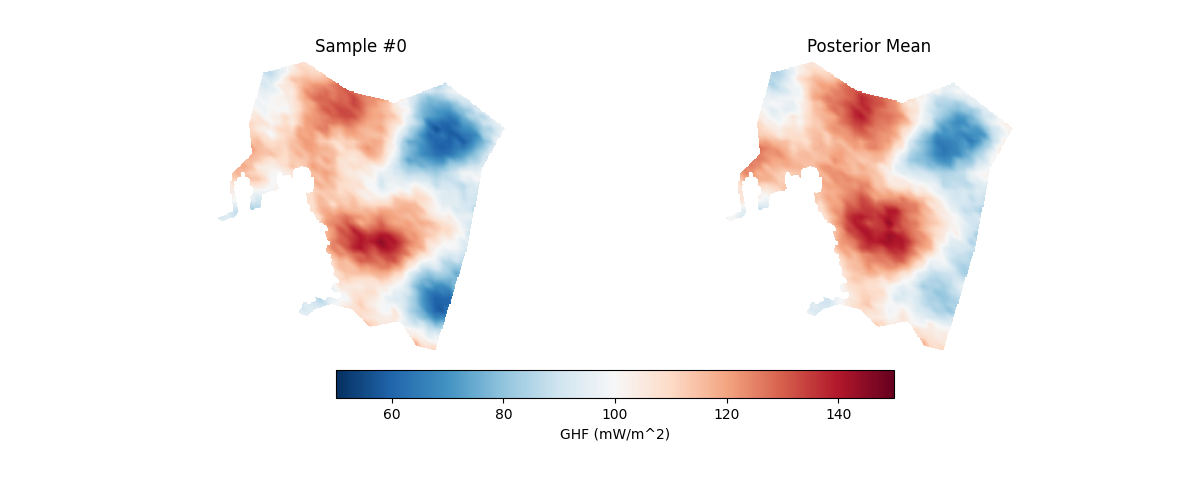

In [17]:

# precompute once
vmin    = 50
vmax    = 150
GHF_mean = GHF_samples.mean(axis=0).reshape(nx, ny)

# ── build figure once, update data in-place ───────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
plt.subplots_adjust(bottom=0.15)

im0 = axes[0].imshow(GHF_samples[0].reshape(nx, ny),
                     vmin=vmin, vmax=vmax, cmap='RdBu_r', origin='lower')
im1 = axes[1].imshow(GHF_mean,
                     vmin=vmin, vmax=vmax, cmap='RdBu_r', origin='lower')

for ax in axes:
    ax.axis('off')
axes[1].set_title('Posterior Mean')

plt.colorbar(im0, ax=axes, orientation='horizontal',
             label='GHF (mW/m^2)', shrink=0.6, pad=0.05)

title = axes[0].set_title('Sample #0')

def update(sample_idx):
    im0.set_data(GHF_samples[sample_idx].reshape(nx, ny))
    title.set_text(f'Sample #{sample_idx}')
    fig.canvas.draw_idle()   # ← only redraws changed pixels, very fast

slider = widgets.IntSlider(
    value=0, min=0, max=num_GHF_samples - 1, step=1,
    description='Sample:', continuous_update=True,   # ← updates while dragging
    layout=widgets.Layout(width='500px')
)
play = widgets.Play(
    value=0, min=0, max=num_GHF_samples - 1,
    step=1, interval=300
)
widgets.jslink((play, 'value'), (slider, 'value'))
widgets.interactive_output(update, {'sample_idx': slider})

display(widgets.VBox([widgets.HBox([play, slider])]))
